# 4 · Validation

In the previous step, we checked whether **satellites** sample the tidal cycle well enough. This step,
checks whether the **tide model itself** is trustworthy at your site.

Every satellite scene in the workflow gets a tide height from **FES2022**. If that model
systematically over- or under-predicts water level, your intertidal elevation map will
be shifted — even with perfect satellite coverage.

We compare FES2022 to **Rijkswaterstaat tide-gauge** measurements via **`rws-ddlpy`** —
Deltares' Python wrapper for Rijkswaterstaat WaterWebservices. This page is
**optional but strongly recommended** for Dutch sites where a nearby gauge exists.

**What this notebook answers**

1. Does FES2022 **track** observed water levels over a full year?
2. Is there a **constant bias** (datum mismatch NAP ↔ MSL)?
3. Are errors **larger at high or low tide** (non-astronomical forcing)?
4. Is the model **good enough** to tag scenes for pages 5–6?

**Metrics at a glance**

| Metric | Meaning |
|---|---|
| **Bias** | Mean(modelled − observed). A constant offset — fix with `NAP_MSL_OFFSET_M`. |
| **MAE** | Mean absolute error — the most useful single number for elevation mapping. |
| **RMSE** | Like MAE but penalises large outliers (storms, surges). |
| **r** | Pearson correlation. High r with large bias → correct phase, wrong datum. |
| **Skill** | Nash–Sutcliffe (1 − MSE/var). 1 = perfect; < 0 = worse than the mean tide. |

**Rule of thumb**

| Metric | Good | Acceptable | Poor |
|---|---|---|---|
| **\|Bias\|** | < 5 cm | 5–10 cm | > 10 cm — fix datum first |
| **MAE** | < 10 cm | 10–20 cm | > 20 cm — investigate |
| **r** | > 0.95 | 0.90–0.95 | < 0.90 |
| **Skill** | > 0.90 | 0.75–0.90 | < 0.75 |


**Previous:** [3 · Tides](03_tides.ipynb) · **Next:** [5 · NDWI](05_ndwi.ipynb)

## Step 1 - Imports

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import ddlpy

# cache_utils wraps both the RWS download (load_or_compute_gauge) and the
# FES2022 tide series (load_or_compute_tides) — shared with page 3.
from cache_utils import load_or_compute_tides, load_or_compute_gauge, list_gauge_stations

warnings.filterwarnings("ignore")

# All saved figures go into outputs/
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Imports OK. ddlpy:", ddlpy.__version__)

Imports OK. ddlpy: 0.10.0


## Step 2 - Configuration

Choose the **RWS tide-gauge closest to your study site**. The FES2022 model is evaluated
at the *gauge coordinates*, so pick a station within ~10–20 km of the flats you will map.

| Legacy code | Location | ddlpy id |
|---|---|---|
| `DENHDR` | Den Helder | `denhelder.marsdiep` |
| `HARLGN` | Harlingen | `harlingen.waddenzee` |
| `DELFZL` | Delfzijl | `delfzijl` |
| `VLISSGN` | Vlissingen | `vlissingen` |
| `YERSEKE` | Yerseke | `yerseke` |

**`NAP_MSL_OFFSET_M`** corrects the datum difference between the gauge (NAP) and FES2022
(MSL). Start at `0.0`. If Step 5 shows a stable constant bias, set this to roughly
`−bias` and re-run. At most Dutch open-coast stations, NAP ≈ MSL so the offset is small.

Use the optional search cell below to find stations by place name.

In [2]:
# Optional: search available WATHTE stations by place name.
# Try: 'hoek', 'harlingen', 'vlissingen', 'yerseke', 'delfzijl'
list_gauge_stations("den helder")

,Code,Naam,Lat,Lon,Groepering.Code
0,denhelder.marsdiep,"Den Helder, Marsdiep",52.964359,4.744990,
2,denhelder.veersteiger,"Den Helder, veersteiger",52.963274,4.778047,


In [3]:
# === EDIT THESE ===
STATION_CODE     = "DENHDR"     # legacy code or ddlpy id (e.g. denhelder.marsdiep)
SITE_NAME        = "Den Helder"

TIDE_DIR         = "./tide_models"
TIDE_MODEL       = "FES2022"

START            = "2023-01-01"  # use the same period as page 3 where possible
END              = "2023-12-31"
NAP_MSL_OFFSET_M = 0.0           # metres; refine if Step 5 shows a constant bias

OVERWRITE = False  # set True to re-download gauge data

os.environ["EO_TIDES_TIDE_MODELS"] = TIDE_DIR
print(f"Station : {STATION_CODE}  ({SITE_NAME})")
print(f"Window  : {START} to {END}")
print(f"NAP-MSL : {NAP_MSL_OFFSET_M:+.3f} m")

Station : DENHDR  (Den Helder)
Window  : 2023-01-01 to 2023-12-31
NAP-MSL : +0.000 m


## Step 3 - Gauge data

`load_or_compute_gauge` looks up the station coordinates, then either loads the
cached Parquet or downloads from the RWS DDL API (1–3 minutes for a full year).

The gauge reports in **cm + NAP**; we convert to **metres + MSL** for comparison
with FES2022. RWS WATHTE data are quality-controlled so cleaning is minimal — we
only drop obvious outliers (values outside ±5 m).

**What to check**

| Output line | Good | Warning |
|---|---|---|
| **Clean records** | Thousands of hourly points | Very few rows — wrong sensor or dates |
| **Range (MSL)** | Matches expected tidal amplitude | Near-flat signal — wrong quantity |
| **Station coords** | Near your study site | Far from AOI — validation less representative |

In [4]:
# Download (or load from cache) the RWS water-level series.
# Returns a DataFrame (gauge_df) and a metadata dict (meta) with lon/lat/name.
gauge_df, meta = load_or_compute_gauge(
    station_code=STATION_CODE,
    start=START, end=END,
    nap_msl_offset_m=NAP_MSL_OFFSET_M,
    overwrite=OVERWRITE,
)

gauge_lon, gauge_lat = meta["lon"], meta["lat"]

# Ensure 'time' is a column (cache may return it as index)
if "time" not in gauge_df.columns:
    gauge_df = gauge_df.reset_index()

print(f"Station coords : {gauge_lat:.4f} N, {gauge_lon:.4f} E")
print(f"Clean records  : {len(gauge_df):,}")
print(f"Range          : {gauge_df['water_level_m_MSL'].min():.3f} m to "
      f"{gauge_df['water_level_m_MSL'].max():.3f} m (MSL)")

  Loaded from cache ← cache/gauge_DENHDR_2023-01-01_2023-12-31.parquet  (52,417 rows)
Station coords : 52.9644 N, 4.7450 E
Clean records  : 52,417
Range          : -1.200 m to 0.990 m (MSL)


## Step 4 - Align FES2022 with gauge

We use the same `load_or_compute_tides` cache as page 3. If you already ran that notebook
for the same coordinates and period, the FES2022 series loads in under a second.

Alignment steps:
1. Resample the gauge to **hourly means** (RWS is ~10 min; hourly is sufficient).
2. For each gauge timestamp, pick the **nearest FES2022 value** within ±31 min.
3. Drop any hour with no model match — this should be near zero if both series
   cover the same period.

The result `comparison` has two columns, **observed** (gauge) and **modelled** (FES2022),
on the same timestamps and in the same datum (MSL).

In [5]:
# Resample gauge to hourly — handles the ~10-min RWS reporting interval
gauge_hourly = (gauge_df.set_index("time")["water_level_m_MSL"]
                .resample("h").mean().dropna())

# Load (or compute) the FES2022 series evaluated at the gauge location.
# Reuses the page-3 cache if site name, dates, and TIDE_DIR match.
heights_full = load_or_compute_tides(
    lon=gauge_lon, lat=gauge_lat,
    start=START, end=END,
    site_name=SITE_NAME,
    tide_model=TIDE_MODEL,
    tide_dir=TIDE_DIR,
    overwrite=OVERWRITE,
)

# Match modelled values to observed timestamps, tolerance = half the 30-min step
modelled = heights_full.reindex(
    gauge_hourly.index, method="nearest", tolerance=pd.Timedelta("31min")
)
modelled.name = "fes2022_m_MSL"

# Paired dataset: only keep hours where both gauge and model are available
comparison = pd.DataFrame({
    "observed": gauge_hourly,
    "modelled": modelled,
}).dropna()

print(f"Matched {len(comparison):,} hourly pairs.")

if len(comparison) < 1000:
    print("⚠  Fewer than 1000 pairs — check START/END or re-run with OVERWRITE=True.")

  Loaded from cache ← cache/tides_Den_Helder_2023-01-01_2023-12-31.parquet  (17,473 rows)
Matched 8,737 hourly pairs.


## Step 5 - Validation metrics

Standard hydrographic statistics, printed with rule-of-thumb flags. These numbers
belong in your **methods / uncertainty section** when citing FES2022.

> **Note on meteorological effects:** FES2022 is a barotropic *astronomical* model.
> Gauge observations include weather effects (storm surges, wind set-up). Some mismatch
> is expected in winter and does not automatically disqualify the model for intertidal
> mapping — surges are episodic, satellite scenes are filtered by cloud cover, and
> the two rarely coincide perfectly. What matters is the **overall MAE**.

In [6]:
# Compute all metrics on the paired time series
diff = comparison["modelled"] - comparison["observed"]  # positive = model too high
bias = float(diff.mean())
mae  = float(diff.abs().mean())
rmse = float(np.sqrt((diff**2).mean()))
r    = float(comparison.corr().iloc[0, 1])
ss   = float(1 - (diff**2).mean() / comparison["observed"].var())  # Nash-Sutcliffe skill

print(f"Validation — FES2022 vs RWS gauge ({STATION_CODE}, {START}–{END})")
print(f"  n      : {len(comparison):,}")
print(f"  Bias   : {bias:+.4f} m  ({bias*100:+.1f} cm)")
print(f"  MAE    : {mae:.4f} m  ({mae*100:.1f} cm)")
print(f"  RMSE   : {rmse:.4f} m  ({rmse*100:.1f} cm)")
print(f"  r      : {r:.4f}")
print(f"  Skill  : {ss:.4f}")

# Rule-of-thumb flags — same thresholds as the intro table
flags = []
if abs(bias) > 0.10:
    flags.append(f"LARGE BIAS ({bias*100:+.1f} cm) — adjust NAP_MSL_OFFSET_M before mapping")
elif abs(bias) > 0.05:
    flags.append(f"MODERATE BIAS ({bias*100:+.1f} cm) — consider tuning NAP_MSL_OFFSET_M")
if mae > 0.20:
    flags.append(f"HIGH MAE ({mae*100:.0f} cm) — investigate station, datum, or surges")
elif mae > 0.10:
    flags.append(f"MODERATE MAE ({mae*100:.0f} cm) — report as tide uncertainty in methods")
if r < 0.90:
    flags.append(f"LOW CORRELATION (r={r:.3f}) — model may not represent this site")
elif r < 0.95:
    flags.append(f"MODERATE CORRELATION (r={r:.3f}) — acceptable if MAE is low")
if ss < 0.75:
    flags.append(f"LOW SKILL ({ss:.3f}) — model barely beats the mean tide")

status = "OK" if not flags else "WARNING"
print()
print("=" * 60)
print(f"[{status}] FES2022 validation — {SITE_NAME}")
print("=" * 60)
for f in flags:
    print(f"  ⚠  {f}")
if not flags:
    print("  ✓  All rule-of-thumb checks passed.")
print()

# Overall go/no-go verdict
if status == "OK" and mae < 0.10:
    print("OVERALL: GOOD — proceed to page 5 (NDWI).")
elif mae < 0.20 and r > 0.90:
    print("OVERALL: CAUTION — mapping may work; report MAE and note meteorological mismatch.")
else:
    print("OVERALL: POOR — fix datum offset or station choice before page 6 (elevation).")
print("=" * 60)

Validation — FES2022 vs RWS gauge (DENHDR, 2023-01-01–2023-12-31)
  n      : 8,737
  Bias   : +0.0007 m  (+0.1 cm)
  MAE    : 0.1069 m  (10.7 cm)
  RMSE   : 0.1346 m  (13.5 cm)
  r      : 0.9690
  Skill  : 0.9258

[WARNING] FES2022 validation — Den Helder
  ⚠  MODERATE MAE (11 cm) — report as tide uncertainty in methods

OVERALL: CAUTION — mapping may work; report MAE and note meteorological mismatch.


## Step 6 - Visualise

Three panels that help you **trust** the numbers above:

| Panel | What to look for |
|---|---|
| **Time series** | FES2022 (red dashed) follows gauge (blue) in phase. A constant vertical shift = datum offset. |
| **Scatter** | Points hug the 1:1 line. A parallel offset = bias; spread = random noise or surges. |
| **Error histogram** | Narrow bell centred on zero. A shifted peak = bias; fat tails = storm events. |

The time series shows July for readability; all metrics use the **full year**.

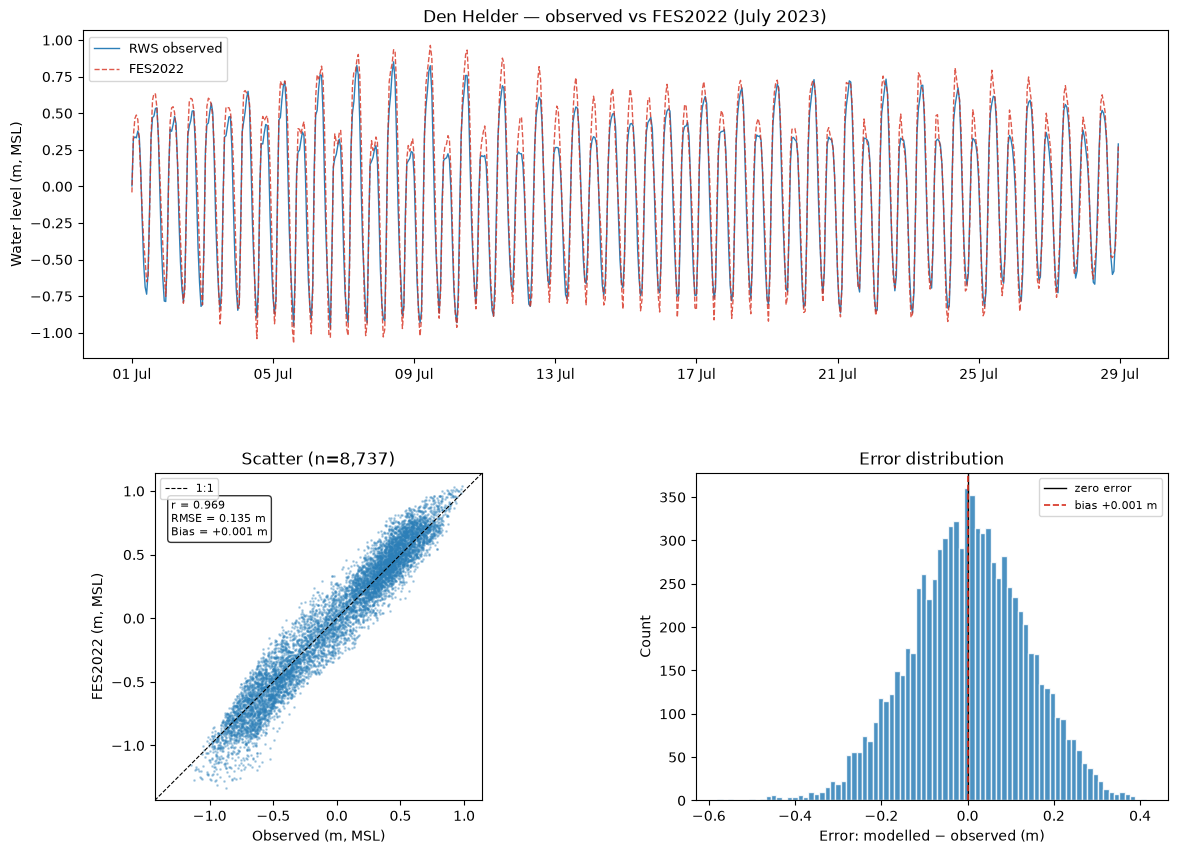

In [7]:
fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.35, wspace=0.3)

# --- Top: 4-week time series to assess phase and amplitude ---
ax1 = fig.add_subplot(gs[0, :])
win = comparison.loc["2023-07-01":"2023-07-28"]
ax1.plot(win.index, win["observed"], lw=1.0, color="#2c7fb8", label="RWS observed")
ax1.plot(win.index, win["modelled"], lw=1.0, color="#d7301f",
         alpha=0.8, ls="--", label="FES2022")
ax1.set_ylabel("Water level (m, MSL)")
ax1.set_title(f"{SITE_NAME} — observed vs FES2022 (July 2023)")
ax1.legend(fontsize=9)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# --- Bottom left: scatter of all matched pairs ---
ax2 = fig.add_subplot(gs[1, 0])
vmin = comparison.min().min() - 0.1
vmax = comparison.max().max() + 0.1
ax2.scatter(comparison["observed"], comparison["modelled"],
            s=1, alpha=0.3, color="#2c7fb8", rasterized=True)
ax2.plot([vmin, vmax], [vmin, vmax], "k--", lw=0.8, label="1:1")  # perfect agreement line
ax2.set_xlabel("Observed (m, MSL)")
ax2.set_ylabel("FES2022 (m, MSL)")
ax2.set_title(f"Scatter (n={len(comparison):,})")
ax2.set_xlim(vmin, vmax); ax2.set_ylim(vmin, vmax)
ax2.set_aspect("equal")
ax2.text(0.05, 0.92,
         f"r = {r:.3f}\nRMSE = {rmse:.3f} m\nBias = {bias:+.3f} m",
         transform=ax2.transAxes, fontsize=8, va="top",
         bbox=dict(boxstyle="round", fc="white", alpha=0.8))
ax2.legend(fontsize=8)

# --- Bottom right: distribution of (modelled - observed) errors ---
ax3 = fig.add_subplot(gs[1, 1])
ax3.hist(diff.values, bins=80, color="#2c7fb8", edgecolor="white", alpha=0.85)
ax3.axvline(0,    color="k",       lw=1,   ls="-",  label="zero error")
ax3.axvline(bias, color="#d7301f", lw=1.2, ls="--", label=f"bias {bias:+.3f} m")
ax3.set_xlabel("Error: modelled − observed (m)")
ax3.set_ylabel("Count")
ax3.set_title("Error distribution")
ax3.legend(fontsize=8)

fig.savefig(OUTPUT_DIR / f"{SITE_NAME.replace(' ','_')}_FES2022_validation.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Step 7 - RMSE by tidal phase

Splitting the error by observed tide height reveals whether FES2022 performs **uniformly**
or is worse at the extremes. This matters because the elevation method depends most on
accuracy near HAT and LAT.

FES2022 is astronomical-only. Gauge data include **meteorological** effects (surges,
wind set-up). Errors near high tide in winter are common on the Dutch coast and do not
alone disqualify the model.

| Bar pattern | Meaning | Action |
|---|---|---|
| **Flat** (uniform RMSE) | Errors are random or datum-only | Constant `NAP_MSL_OFFSET_M` fix appropriate |
| **U-shape** | Datum offset + extra error at extremes | Fix datum first; expect residual at HAT/LAT |
| **High bars at high tide only** | Storm surges; expected in winter | Often acceptable — note in methods |
| **One isolated high bar** | Single storm event | Check time series for outliers |

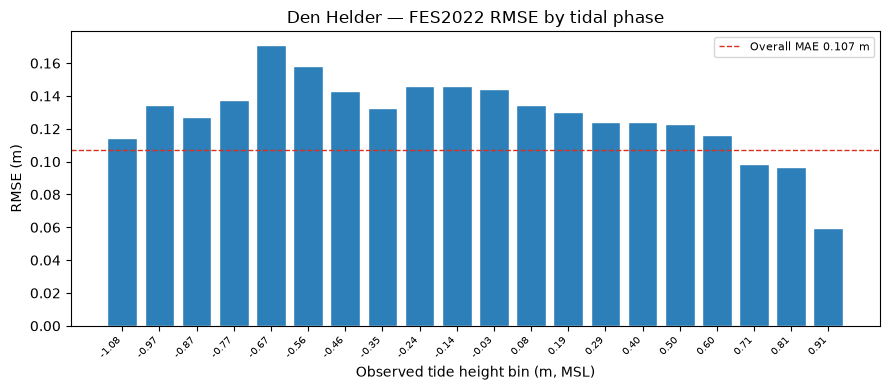

In [8]:
# Bin the observations by tide height and compute RMSE per bin
n_bins = 20
comparison["obs_bin"] = pd.cut(comparison["observed"], bins=n_bins)
bin_rmse = comparison.groupby("obs_bin", observed=True).apply(
    lambda g: np.sqrt(((g["modelled"] - g["observed"]) ** 2).mean())
)
bin_centres = comparison.groupby("obs_bin", observed=True)["observed"].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(bin_rmse)), bin_rmse.values, color="#2c7fb8", edgecolor="white")
ax.set_xticks(range(len(bin_centres)))
ax.set_xticklabels(
    [f"{v:.2f}" for v in bin_centres.values], rotation=45, ha="right", fontsize=7
)
ax.set_xlabel("Observed tide height bin (m, MSL)")
ax.set_ylabel("RMSE (m)")
ax.set_title(f"{SITE_NAME} — FES2022 RMSE by tidal phase")

# Reference line: overall MAE (easier to compare against than overall RMSE)
ax.axhline(mae, color="#d7301f", ls="--", lw=1, label=f"Overall MAE {mae:.3f} m")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SITE_NAME.replace(' ','_')}_FES2022_RMSE_phase.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Step 8 - Summary

You have now validated the tide model that underpins the rest of the tutorial in four steps:

1. **Gauge data** — RWS WATHTE at the nearest station, converted to metres MSL.
2. **Model predictions** — FES2022 at the gauge coordinates, matched hour by hour.
3. **Statistics** — bias, MAE, RMSE, r, skill, with a printed go/no-go verdict.
4. **Visual and phase checks** — time series, scatter, error histogram, RMSE by bin.

Nothing here downloads satellite pixels. You are verifying that the **tide tag** applied
to every scene in page 3 is defensible before pages 5–6 use it for NDWI and elevation.

### Go / no-go

| Situation | Action |
|---|---|
| **GOOD** + scatter on 1:1 line | Proceed — cite FES2022 and report MAE |
| **CAUTION**, high r, MAE 10–20 cm | Proceed — report MAE as ± uncertainty on tide tags |
| Large constant bias, high r | Fix datum: set `NAP_MSL_OFFSET_M ≈ −bias`, re-run from gauge step |
| Low r or MAE > 20 cm | Stop — wrong gauge, period, or model path |
| High RMSE only at high tide (Step 7) | Often acceptable — astronomical model vs. surges |

---

:::{dropdown} Cache files
```
cache/
  gauge_<station>_<start>_<end>.parquet   ← RWS WATHTE download
  tides_<site>_<start>_<end>.parquet      ← FES2022 series (shared with page 3)
```
Set `OVERWRITE = True` when changing station, dates, or `NAP_MSL_OFFSET_M`.
:::

**References:**
Lyard et al. (2021) *Ocean Science*; Bishop-Taylor et al. (2019) *ECSS*.

**Next:** [5 · NDWI](05_ndwi.ipynb)